In [ ]:
# USE GPU

import torch
torch.tensor([1., 2., 3.], device = 'cuda')

tensor([1., 2., 3.], device='cuda:0')

In [4]:
torch.cuda.is_available()

True

In [10]:
a = torch.tensor([1.0, 2.0, 3.0]).cuda()
b = torch.tensor([4.0, 5.0, 6.0]).cuda()
a * b

tensor([ 4., 10., 18.], device='cuda:0')

In [ ]:
lin = torch.nn.Linear(3, 2).cuda()
# 입력 3개를 -> 출력 2개로 변환하는 레이어
# CPU -> GPU

dummy = torch.randn(5, 3).cuda()
lin(dummy)


# dummy = torch.randn(5,3)
# lin(dummy)
# dummy - CPU,  lin - GPU

tensor([[ 0.9360, -2.7312, -1.8495],
        [-1.0964, -0.4332, -1.1121],
        [ 0.6978,  1.0261, -1.0746],
        [ 0.6120,  1.0567,  0.6487],
        [ 0.3489,  0.8551,  0.0591]], device='cuda:0')

In [ ]:
act = torch.nn.RELU()
act.cuda()
dummy = torch.randn(5)
act(dummy)

# 얘는 왜 .cuda()를 안쓰는데 오류가 안나?
# ReLU는 파라미터(가중치)가 없기 때문임

Parameter containing:
tensor([[-0.5725, -0.2586, -0.0902],
        [-0.2600,  0.4246, -0.4115]], device='cuda:0', requires_grad=True)

In [ ]:







# GPU








In [19]:
import torch
from torch import nn
import torchvision
import matplotlib.pyplot as plt

mnist_train = torchvision.datasets.FashionMNIST('.', train=True, download=True)
mnist_valid = torchvision.datasets.FashionMNIST('.', train=False, download=True)

x_train = mnist_train.data.reshape(-1, 1, 28, 28) / 255     #.data - 이미지 픽셀 데이터
y_train = mnist_train.targets  #.targets - 라벨 (정답 숫자 0~9)

x_valid = mnist_valid.data.reshape(-1, 1, 28, 28) / 255
y_valid = mnist_valid.targets

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

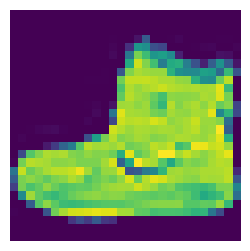

In [20]:
sample = x_train[0][0]
plt.figure(figsize=(3,3))
plt.imshow(sample)
plt.axis('off')

In [21]:
dataset_train = list(zip(x_train, y_train))
dataset_valid = list(zip(x_valid, y_valid))

# x_train(이미지) + y_train(라벨)을 쌍으로 묶음
# [(이미지0, 라벨0), (이미지1, 라벨1), ...]

loader_train = torch.utils.data.DataLoader(dataset_train, batch_size = 32)
loader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size = 32)
# 데이터를 32개씩 묶어서 꺼내주는 객체   60000 / 32 = 1875

for x, y in loader_train:
    break

x.shape, y.shape, x.dtype, y.dtype, x.min(), x.max()

(torch.Size([32, 1, 28, 28]),
 torch.Size([32]),
 torch.float32,
 torch.int64,
 tensor(0.),
 tensor(1.))

In [22]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(32, 32, kernel_size=3, padding=1),
    nn.ReLU(),

    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(64, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    

    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(128, 128, kernel_size=3, padding=1),
    nn.ReLU(),
    
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(128, 10)
    
)

model.to(device) # 제자리 연산 모델 내부의 모든 파라미터가 GPU로 변경

opt = torch.optim.Adam(model.parameters())

#loss_fn = torch.nn.CrossEntropyLoss()
loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.2)


# 테스트
logit = model(x.to(device))
loss = loss_fn(logit, y.to(device))
loss.backward()

In [30]:
from torchinfo import summary
summary(model, imput_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Conv2d: 1-1                            320
├─ReLU: 1-2                              --
├─Conv2d: 1-3                            9,248
├─ReLU: 1-4                              --
├─MaxPool2d: 1-5                         --
├─Conv2d: 1-6                            18,496
├─ReLU: 1-7                              --
├─Conv2d: 1-8                            36,928
├─ReLU: 1-9                              --
├─MaxPool2d: 1-10                        --
├─Conv2d: 1-11                           73,856
├─ReLU: 1-12                             --
├─Conv2d: 1-13                           147,584
├─ReLU: 1-14                             --
├─AdaptiveAvgPool2d: 1-15                --
├─Flatten: 1-16                          --
├─Linear: 1-17                           1,290
Total params: 287,722
Trainable params: 287,722
Non-trainable params: 0

In [35]:
# ---------------------------

# 학습 루프

for epoch in range(30):
    total_loss = 0
    total_acc = 0
    for step, (x, y) in enumerate(loader_train):
        x = x.to(device)
        y = y.to(device)

        logit = model(x)
        loss = loss_fn(logit, y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        
        #metrics - acc 
        total_loss += loss.item()
        pred = logit.argmax(axis=1)
        total_acc += (pred == y).float().mean().item()
        
    print('\r epoch=%d,    step=%d    loss=%.4f    acc=%.4f' %
            (epoch, step, total_loss/(step+1), total_acc/(step+1)), end='')
    
    print()  # ← epoch 끝나면 줄바꿈

 epoch=0,    step=1874    loss=0.0942    acc=0.9661
 epoch=1,    step=1874    loss=0.0817    acc=0.9699
 epoch=2,    step=1874    loss=0.0740    acc=0.9719
 epoch=3,    step=1874    loss=0.0678    acc=0.9754
 epoch=4,    step=1874    loss=0.0618    acc=0.9777
 epoch=5,    step=1874    loss=0.0563    acc=0.9791
 epoch=6,    step=1874    loss=0.0545    acc=0.9798
 epoch=7,    step=1874    loss=0.0524    acc=0.9807
 epoch=8,    step=1874    loss=0.0466    acc=0.9828
 epoch=9,    step=1874    loss=0.0477    acc=0.9820
 epoch=10,    step=1874    loss=0.0417    acc=0.9850
 epoch=11,    step=1874    loss=0.0396    acc=0.9854
 epoch=12,    step=1874    loss=0.0398    acc=0.9852
 epoch=13,    step=1874    loss=0.0369    acc=0.9868
 epoch=14,    step=1874    loss=0.0363    acc=0.9870
 epoch=15,    step=1874    loss=0.0346    acc=0.9872
 epoch=16,    step=1874    loss=0.0328    acc=0.9888
 epoch=17,    step=1874    loss=0.0341    acc=0.9878
 epoch=18,    step=1874    loss=0.0309    acc=0.9888
 ep

In [33]:
for epoch in range(10):
    total_loss = 0
    total_acc = 0
    for step, (x, y) in enumerate(loader_valid):
        x = x.to(device)
        y = y.to(device)

        with torch.no_grad():
            logit = model(x)
        loss = loss_fn(logit, y)

        #metrics - acc
        total_loss += loss.item()
        pred = logit.argmax(axis=1)
        acc = (pred == y).float().mean()
        total_acc += acc.item()

        print('\r %s step=%d  loss=%.4f  acc=%.4f' %
         (' ' * 20, step, total_loss / (step+1), total_acc / (step + 1)), end='')

                      step=312  loss=0.3041  acc=0.9125

In [34]:
# 검증...

with torch.no_grad():
    logit = model(x_valid.to(device))

pred = logit.argmax(axis=1)
acc = (pred == y_valid.to(device)).float().mean()
acc

tensor(0.9128, device='cuda:0')